# FCN3 vs GraphCast vs Pangu vs HRES: 10 m Wind Speed – 2022 (+6 h Lead)

Compares four forecast models against hourly station observations.

**Aligned period:** 2022-01-01 → 2022-01-28

| Model | Source | Lead |
|---|---|---|
| FCN3 | Pre-extracted station zarr (fcn3_station_weekly) | +6 h |
| GraphCast | Pre-extracted station zarr (graphcast_station_weekly) | +6 h |
| HRES | ECMWF WeatherBench2 0.25° | +6 h |
| Pangu | Pangu-Weather WeatherBench2 0.25° | +6 h |

> **Note:** The FCN3 and GraphCast station-extracted zarrs store only lead = [0, 6] h.
> All models are evaluated at **+6 h** for a fair apples-to-apples comparison.

| Station ID | Name | Lat | Lon |
|---|---|---|---|
| SN88690 | Hekkingen Fyr | 69.60 N | 17.83 E |
| SN90490 | Tromsø-Langnes | 69.68 N | 18.91 E |
| SN90760 | Fakken | 70.10 N | 20.11 E |


In [47]:
import warnings
warnings.filterwarnings('ignore')

# nest_asyncio lets zarr v3 async code run inside Jupyter's existing event loop
import nest_asyncio
nest_asyncio.apply()

import zarr
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print('zarr  :', zarr.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)
print('xarray:', xr.__version__)


zarr  : 3.1.6
numpy : 2.4.4
pandas: 3.0.3
xarray: 2026.4.0


In [48]:
# ── Paths ──────────────────────────────────────────────────────────────────
FCN3_DIR  = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/fcn3_station_weekly/2022_2025')
GC_DIR    = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/graphcast_station_weekly/2022_2025')
HRES_PATH = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')
PANGU_PATH = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/pangu/0p25/2018-2022_0012_0p25.zarr')
OBS_DIR   = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')

FIG_DIR = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

# ── Experiment settings ─────────────────────────────────────────────────────
# FCN3 and GraphCast station-extracted zarrs only store lead = [0, 6] h.
# All models are compared at +6 h for a fair apples-to-apples evaluation.
LEAD_H       = 6
PERIOD_START = '2022-01-01'
PERIOD_END   = '2022-01-28'

# ── Station metadata ────────────────────────────────────────────────────────
STATIONS = {
    'SN88690': {'name': 'Hekkingen Fyr',  'lat': 69.6005,  'lon': 17.8317},
    'SN90490': {'name': 'Tromsø-Langnes', 'lat': 69.6767,  'lon': 18.9133},
    'SN90760': {'name': 'Fakken',          'lat': 70.10426, 'lon': 20.11451},
}

OBS_STATION_NAMES = {
    'SN88690': 'SN88690_Hekkingen_Fyr',
    'SN90490': 'SN90490_Tromsoe_Langnes',
    'SN90760': 'SN90760_Fakken',
}

CLR = {
    'FCN3':      '#E74C3C',
    'GraphCast': '#2980B9',
    'Pangu':     '#16A085',
    'HRES':      '#E67E22',
    'Obs':       '#27AE60',
}


Figures → /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022


## 1  Load Observations

In [49]:
def load_observations(obs_dir: Path, obs_station_names: dict,
                      start: str, end: str) -> pd.DataFrame:
    """Load hourly per-year obs CSVs and compute 12-hour trailing mean per station.

    obs_station_names: {station_id: file_base_name}
      e.g. 'SN88690' -> 'SN88690_Hekkingen_Fyr'
    Files are expected as <base_name>_<year>.csv.
    """
    start_yr = pd.Timestamp(start).year
    end_yr   = pd.Timestamp(end).year

    dfs = []
    for sid, base in obs_station_names.items():
        parts = []
        for yr in range(start_yr, end_yr + 1):
            f = obs_dir / f'{base}_{yr}.csv'
            if not f.exists():
                print(f'  Warning: {f.name} not found, skipping.')
                continue
            df = pd.read_csv(f)
            df['valid_time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
            df['station'] = sid
            df = df.rename(columns={'wind_speed': 'obs_wind'})
            parts.append(df[['station', 'valid_time', 'obs_wind']].dropna(subset=['obs_wind']))

        if not parts:
            continue

        sdf = pd.concat(parts, ignore_index=True).sort_values('valid_time')
        # 12-hour trailing mean; require at least 6 obs in window
        sdf['obs_wind'] = (
            sdf.set_index('valid_time')['obs_wind']
            .rolling('12h', min_periods=6)
            .mean()
            .values
        )
        dfs.append(sdf.dropna(subset=['obs_wind']))

    obs = pd.concat(dfs, ignore_index=True)
    obs = obs[(obs['valid_time'] >= start) & (obs['valid_time'] <= end)]
    return obs


obs_df = load_observations(OBS_DIR, OBS_STATION_NAMES, PERIOD_START, PERIOD_END)
print(f'Observations (12h trailing mean): {len(obs_df):,} rows')
print(f'  Time range : {obs_df["valid_time"].min()} → {obs_df["valid_time"].max()}')
obs_df.head(3)


Observations (12h trailing mean): 1,917 rows
  Time range : 2022-01-01 05:00:00 → 2022-01-28 00:00:00


,station,valid_time,obs_wind
0,SN88690,2022-01-01 05:00:00,7.65
1,SN88690,2022-01-01 06:00:00,8.20
2,SN88690,2022-01-01 07:00:00,8.40


## 2  Load FCN3 and GraphCast (Pre-Extracted Station Zarrs)

In [50]:
def load_station_weekly(zarr_path: Path, lead_h: float, col_name: str) -> pd.DataFrame:
    """Load pre-extracted station zarr (shape: station × time × lead_time).
    Uses xr.open_zarr to avoid zarr-v3 async conflicts inside Jupyter.
    lead_time is decoded by xarray as timedelta64[s].
    """
    ds = xr.open_zarr(str(zarr_path), consolidated=True)

    stations  = [str(s) for s in ds['station'].values]
    init_times = pd.DatetimeIndex(ds['time'].values)

    # lead_time decoded as timedelta64[s]; match by closest seconds
    target_lt = np.timedelta64(int(lead_h * 3600), 's')
    lt_vals   = ds['lead_time'].values
    lt_idx    = int(np.argmin(np.abs(lt_vals - target_lt)))
    lt_used   = float(lt_vals[lt_idx] / np.timedelta64(1, 's')) / 3600.0  # back to hours

    ws = ds['wind_speed_10m'].values  # (station, time, lead_time)

    records = []
    for s_i, sid in enumerate(stations):
        for t_i, init_t in enumerate(init_times):
            wind = float(ws[s_i, t_i, lt_idx])
            if np.isnan(wind):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': lt_used,
                'valid_time':  init_t + pd.Timedelta(hours=lt_used),
                col_name:      wind,
            })
    return pd.DataFrame(records)


# ── FCN3 ────────────────────────────────────────────────────────────────────
fcn3_files = sorted(FCN3_DIR.glob('fcn3_station_wind_*.zarr'))
fcn3_files = [f for f in fcn3_files
              if pd.Timestamp(f.name.split('_')[-2]) <= pd.Timestamp(PERIOD_END)]
print(f'FCN3 files in period: {len(fcn3_files)}')

fcn3_parts = []
for f in fcn3_files:
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_station_weekly(f, lead_h=LEAD_H, col_name='fcn3_wind')
    fcn3_parts.append(df)
    print(f'{len(df)} records')

fcn3_df = (
    pd.concat(fcn3_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)

# ── GraphCast ────────────────────────────────────────────────────────────────
gc_files = sorted(GC_DIR.glob('graphcast_station_wind_*.zarr'))
gc_files = [f for f in gc_files
            if pd.Timestamp(f.name.split('_')[-2]) <= pd.Timestamp(PERIOD_END)]
print(f'\nGraphCast files in period: {len(gc_files)}')

gc_parts = []
for f in gc_files:
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_station_weekly(f, lead_h=LEAD_H, col_name='gc_wind')
    gc_parts.append(df)
    print(f'{len(df)} records')

gc_df = (
    pd.concat(gc_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)

print(f'\nFCN3 total     : {len(fcn3_df):,}')
print(f'GraphCast total: {len(gc_df):,}')


FCN3 files in period: 4
  fcn3_station_wind_20220101_20220107.zarr ... 84 records
  fcn3_station_wind_20220108_20220114.zarr ... 84 records
  fcn3_station_wind_20220115_20220121.zarr ... 84 records
  fcn3_station_wind_20220122_20220128.zarr ... 84 records

GraphCast files in period: 4
  graphcast_station_wind_20220101_20220107.zarr ... 84 records
  graphcast_station_wind_20220108_20220114.zarr ... 84 records
  graphcast_station_wind_20220115_20220121.zarr ... 84 records
  graphcast_station_wind_20220122_20220128.zarr ... 84 records

FCN3 total     : 336
GraphCast total: 336


## 3  Load HRES and Pangu (WeatherBench2)

In [51]:
# ── HRES ────────────────────────────────────────────────────────────────────
hres_ds = xr.open_zarr(HRES_PATH, consolidated=False)
print('HRES time  :', pd.Timestamp(hres_ds['time'].values[0]), '→',
      pd.Timestamp(hres_ds['time'].values[-1]))
print('HRES leads (h, first 6):', hres_ds['prediction_timedelta'].values[:6])


def load_wb2_at_stations(ds: xr.Dataset, wind_var: str, lat_coord: str,
                          lon_coord: str, lead_coord: str,
                          stations: dict, lead_h: int,
                          start: str, end: str, col_name: str) -> pd.DataFrame:
    """Extract nearest-grid-point 10 m wind from a WeatherBench2 zarr."""
    da = ds[wind_var].sel({lead_coord: lead_h})
    da = da.sel(time=slice(start, end))
    init_times = pd.DatetimeIndex(da['time'].values)
    records = []
    for sid, info in stations.items():
        target_lon = info['lon'] % 360
        ws_vals = da.sel(
            {lat_coord: info['lat'], lon_coord: target_lon}, method='nearest'
        ).values
        for t_i, init_t in enumerate(init_times):
            val = float(ws_vals[t_i])
            if np.isnan(val):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': float(lead_h),
                'valid_time':  init_t + pd.Timedelta(hours=float(lead_h)),
                col_name:      val,
            })
    return pd.DataFrame(records)


hres_df = load_wb2_at_stations(
    hres_ds, wind_var='10m_wind_speed',
    lat_coord='latitude', lon_coord='longitude', lead_coord='prediction_timedelta',
    stations=STATIONS, lead_h=LEAD_H, start=PERIOD_START, end=PERIOD_END,
    col_name='hres_wind',
)
hres_df = (
    hres_df.drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time']).reset_index(drop=True)
)
print(f'HRES records: {len(hres_df):,}')

# ── Pangu ────────────────────────────────────────────────────────────────────
# Pangu latitude runs 90→-90 (descending). method='nearest' handles this correctly.
pangu_ds = xr.open_zarr(PANGU_PATH, consolidated=False)
print('\nPangu time  :', pd.Timestamp(pangu_ds['time'].values[0]), '→',
      pd.Timestamp(pangu_ds['time'].values[-1]))
print('Pangu leads (h, first 6):', pangu_ds['prediction_timedelta'].values[:6])

pangu_df = load_wb2_at_stations(
    pangu_ds, wind_var='10m_wind_speed',
    lat_coord='latitude', lon_coord='longitude', lead_coord='prediction_timedelta',
    stations=STATIONS, lead_h=LEAD_H, start=PERIOD_START, end=PERIOD_END,
    col_name='pangu_wind',
)
pangu_df = (
    pangu_df.drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time']).reset_index(drop=True)
)
print(f'Pangu records: {len(pangu_df):,}')


HRES time  : 2016-01-01 00:00:00 → 2023-01-10 12:00:00
HRES leads (h, first 6): [ 0  6 12 18 24 30]
HRES records: 168

Pangu time  : 2018-01-01 00:00:00 → 2022-12-31 12:00:00
Pangu leads (h, first 6): [ 6 12 18 24 30 36]
Pangu records: 168


## 4  Align Datasets

In [52]:
for _df in [fcn3_df, gc_df, hres_df, pangu_df, obs_df]:
    _df['valid_time'] = _df['valid_time'].astype('datetime64[us]')

# Merge all four models
merged = fcn3_df[['station', 'valid_time', 'fcn3_wind']].copy()
for right_df, right_col in [
    (gc_df,    'gc_wind'),
    (hres_df,  'hres_wind'),
    (pangu_df, 'pangu_wind'),
]:
    merged = pd.merge(merged, right_df[['station', 'valid_time', right_col]],
                      on=['station', 'valid_time'], how='inner')

print(f'FCN3 ∩ GC ∩ HRES ∩ Pangu       : {len(merged):,}')

merged = pd.merge(
    merged,
    obs_df[['station', 'valid_time', 'obs_wind']],
    on=['station', 'valid_time'], how='inner',
).dropna(subset=['fcn3_wind', 'gc_wind', 'hres_wind', 'pangu_wind', 'obs_wind'])
print(f'All models ∩ Obs               : {len(merged):,}')


if len(merged) == 0:
    raise ValueError('No matching records after merge.')

print(f'\nPer station:')
print(merged.groupby('station').size().rename('N'))
print(f'\nValid-time range : {merged["valid_time"].min()} → {merged["valid_time"].max()}')

_avail   = set(merged['station'].unique())
_missing = [s for s in list(STATIONS.keys()) if s not in _avail]
for s in _missing:
    print(f'  Note: {s} excluded — no overlap.')
    del STATIONS[s]
merged.head(5)


FCN3 ∩ GC ∩ HRES ∩ Pangu       : 168
All models ∩ Obs               : 161

Per station:
station
SN88690    53
SN90490    54
SN90760    54
Name: N, dtype: int64

Valid-time range : 2022-01-01 06:00:00 → 2022-01-27 18:00:00


,station,valid_time,fcn3_wind,gc_wind,hres_wind,pangu_wind,obs_wind
0,SN88690,2022-01-01 06:00:00,7.230498,4.670124,5.853451,4.309501,8.200000
1,SN88690,2022-01-01 18:00:00,3.670000,2.599549,2.765058,3.130186,5.075000
2,SN88690,2022-01-02 06:00:00,8.264902,8.087872,7.231346,7.934565,11.725000
3,SN88690,2022-01-02 18:00:00,9.576138,10.766291,9.101218,10.558546,19.541667
4,SN88690,2022-01-03 06:00:00,7.987626,8.765484,7.549736,8.191597,15.850000


## 5  Compute Metrics

In [53]:
MODEL_COLS = {
    'FCN3':      'fcn3_wind',
    'GraphCast': 'gc_wind',
    'HRES':      'hres_wind',
    'Pangu':     'pangu_wind',
}


def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for label, gdf in [*df.groupby('station'), ('All Stations', df)]:
        if len(gdf) == 0:
            continue
        row = {'Station': label, 'N': len(gdf)}
        for mname, wcol in MODEL_COLS.items():
            if wcol not in gdf.columns:
                continue
            sub = gdf.dropna(subset=[wcol])
            if len(sub) == 0:
                continue
            e = sub[wcol] - sub['obs_wind']
            row[f'{mname} RMSE'] = float(np.sqrt((e**2).mean()))
            row[f'{mname} MSE']  = float((e**2).mean())
            row[f'{mname} Bias'] = float(e.mean())
        rows.append(row)
    return pd.DataFrame(rows).set_index('Station')


metrics = compute_metrics(merged)
rmse_cols = [f'{m} RMSE' for m in MODEL_COLS if f'{m} RMSE' in metrics.columns]
mse_cols  = [f'{m} MSE'  for m in MODEL_COLS if f'{m} MSE'  in metrics.columns]
bias_cols = [f'{m} Bias' for m in MODEL_COLS if f'{m} Bias' in metrics.columns]

print('=' * 110)
print(f'Fair Comparison  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 110)
print(metrics[['N', *rmse_cols]].round(4).to_string())
print()
print(metrics[['N', *bias_cols]].round(4).to_string())


Fair Comparison  |  lead = +6 h  |  2022-01-01 → 2022-01-28
                N  FCN3 RMSE  GraphCast RMSE  HRES RMSE  Pangu RMSE
Station                                                            
SN88690        53     3.8279          4.0089     5.1248      3.9412
SN90490        54     3.4951          3.6792     3.9553      3.3582
SN90760        54     7.0823          7.5006     7.2176      7.6102
All Stations  161     5.0739          5.3573     5.6005      5.3218

                N  FCN3 Bias  GraphCast Bias  HRES Bias  Pangu Bias
Station                                                            
SN88690        53    -2.1814         -2.8320    -4.2208     -2.5948
SN90490        54    -2.6552         -2.8418    -3.1200     -2.3949
SN90760        54    -5.3836         -5.9700    -5.4665     -6.0728
All Stations  161    -3.4143         -3.8878    -4.2694     -3.6943


## 6  Time Series

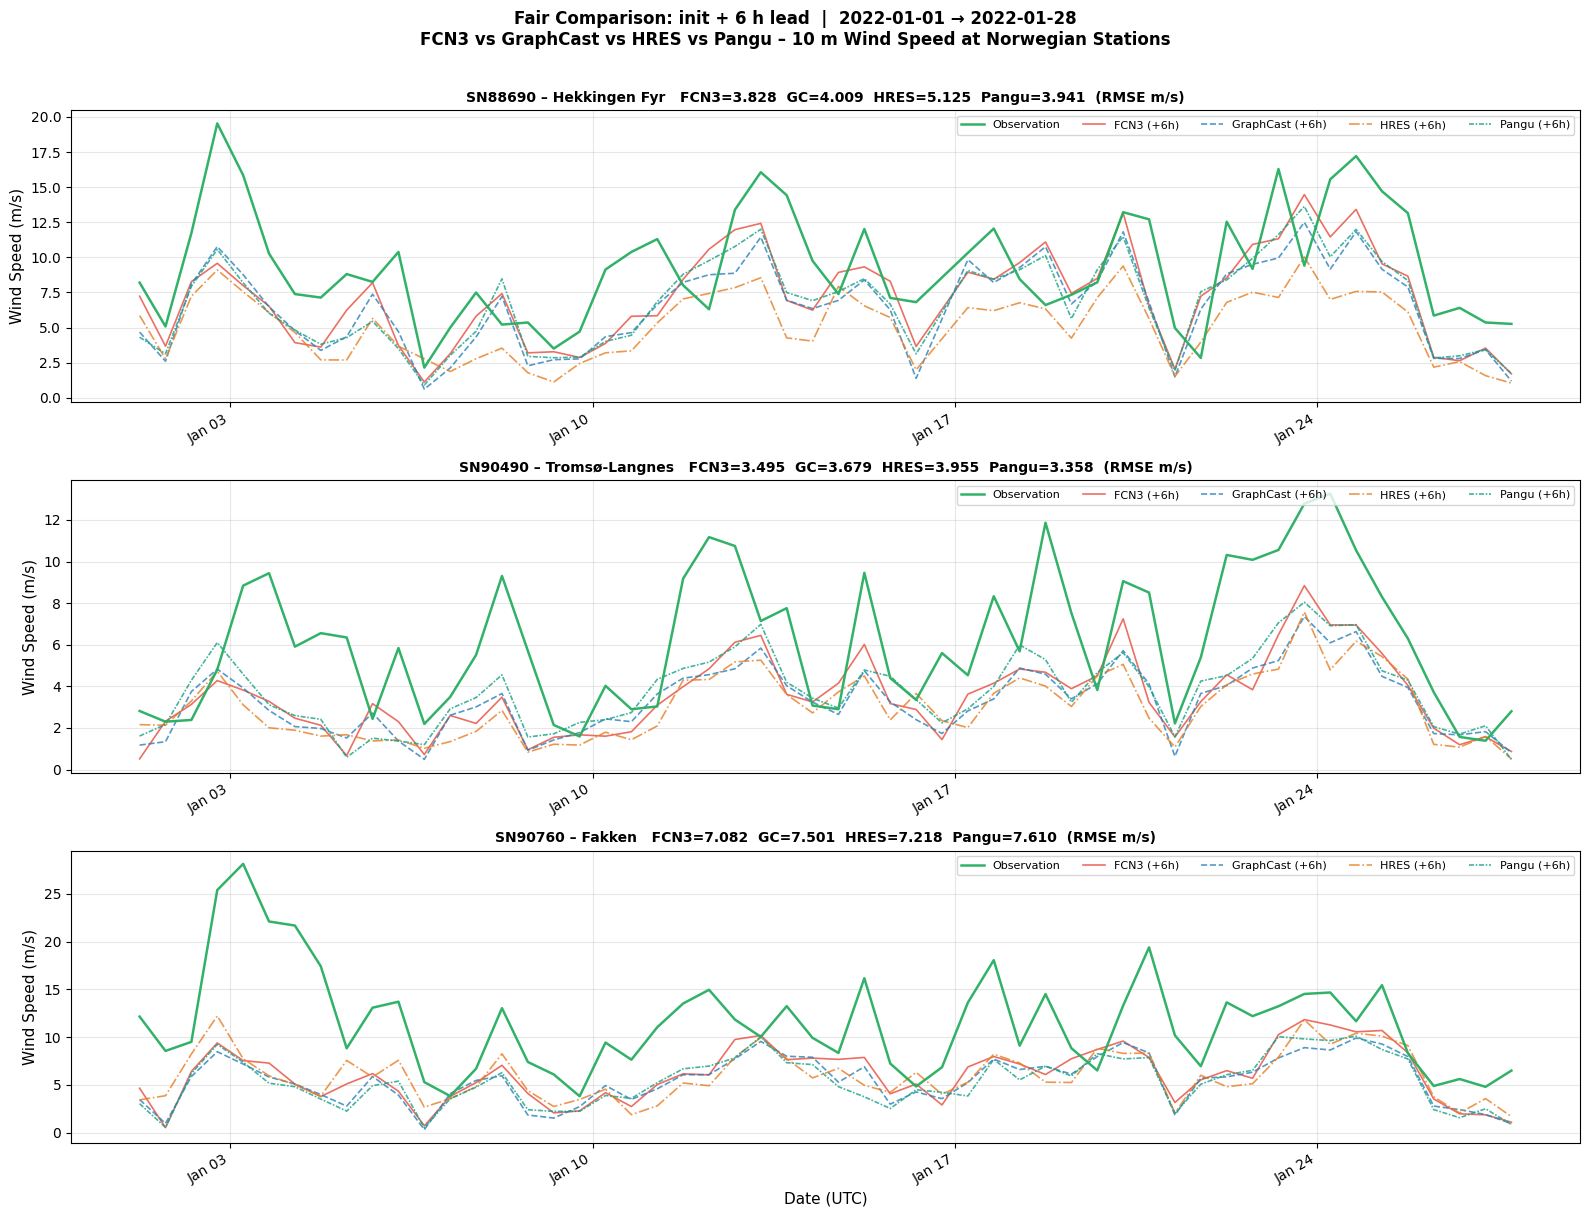

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022/comparison_time_series.png


In [54]:
_n   = len(STATIONS)
fig, axes = plt.subplots(_n, 1, figsize=(16, 4 * _n))
if _n == 1:
    axes = [axes]

for ax, (sid, info) in zip(axes, STATIONS.items()):
    sub = merged[merged['station'] == sid].sort_values('valid_time')
    ax.plot(sub['valid_time'], sub['obs_wind'],
            color=CLR['Obs'],  lw=1.8, label='Observation', alpha=0.95, zorder=5)
    ax.plot(sub['valid_time'], sub['fcn3_wind'],
            color=CLR['FCN3'],      lw=1.2, label=f'FCN3 (+{LEAD_H}h)',      alpha=0.80, zorder=2)
    ax.plot(sub['valid_time'], sub['gc_wind'],
            color=CLR['GraphCast'], lw=1.2, label=f'GraphCast (+{LEAD_H}h)', alpha=0.80, zorder=3, linestyle='--')
    ax.plot(sub['valid_time'], sub['hres_wind'],
            color=CLR['HRES'],  lw=1.2, label=f'HRES (+{LEAD_H}h)',  alpha=0.80, zorder=3, linestyle='-.')
    ax.plot(sub['valid_time'], sub['pangu_wind'],
            color=CLR['Pangu'], lw=1.2, label=f'Pangu (+{LEAD_H}h)', alpha=0.80, zorder=3, linestyle=(0, (3, 1, 1, 1)))

    rf = metrics.loc[sid, 'FCN3 RMSE']
    rg = metrics.loc[sid, 'GraphCast RMSE']
    rh = metrics.loc[sid, 'HRES RMSE']
    rp = metrics.loc[sid, 'Pangu RMSE']
    ax.set_title(
        f'{sid} – {info["name"]}   FCN3={rf:.3f}  GC={rg:.3f}  HRES={rh:.3f}  Pangu={rp:.3f}  (RMSE m/s)',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=5)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[-1].set_xlabel('Date (UTC)', fontsize=11)
fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'FCN3 vs GraphCast vs HRES vs Pangu – 10 m Wind Speed at Norwegian Stations',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
out = FIG_DIR / 'comparison_time_series.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 7  Error Bar Charts

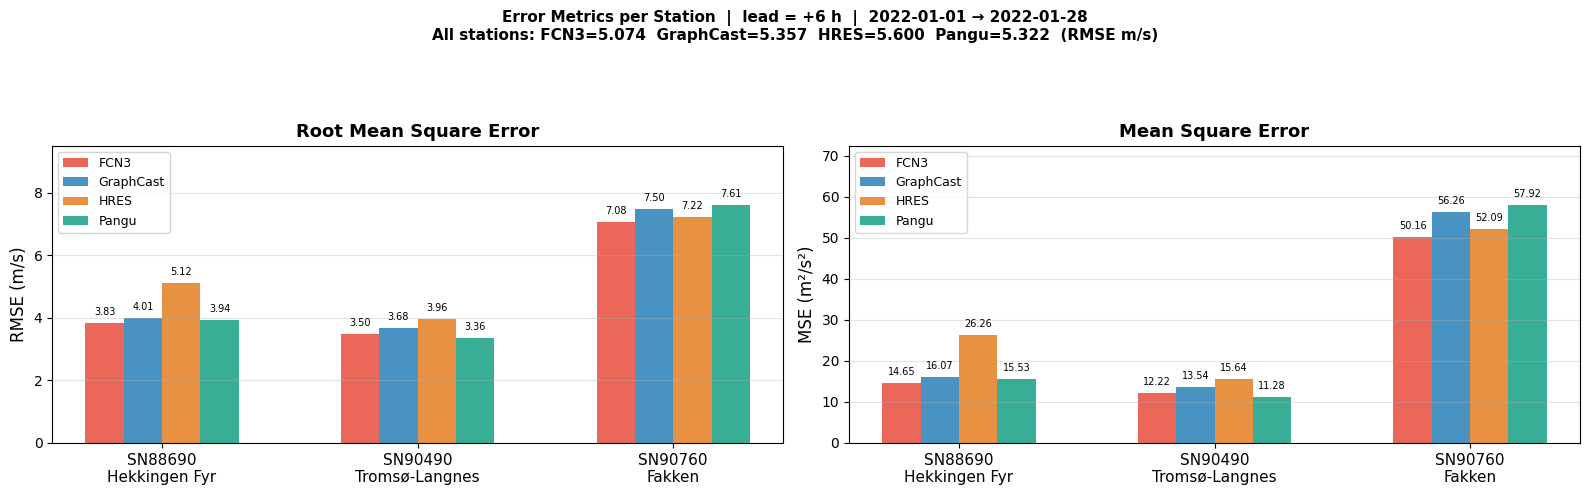

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022/comparison_metrics_bar.png


In [55]:
sids    = list(STATIONS.keys())
labels  = [f'{s}\n{STATIONS[s]["name"]}' for s in sids]
mdf     = metrics.loc[sids]
models  = ['FCN3', 'GraphCast', 'HRES', 'Pangu']
present = [m for m in models if f'{m} RMSE' in mdf.columns]
x       = np.arange(len(sids))
w       = 0.15
offsets = np.linspace(-(len(present) - 1) / 2, (len(present) - 1) / 2, len(present)) * w

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (metric, ylabel, title) in zip(
    axes,
    [('RMSE', 'RMSE (m/s)',   'Root Mean Square Error'),
     ('MSE',  'MSE (m²/s²)', 'Mean Square Error')],
):
    all_bars = []
    for m, offset in zip(present, offsets):
        bars = ax.bar(x + offset, mdf[f'{m} {metric}'], w,
                      label=m, color=CLR[m], alpha=0.85)
        all_bars.extend(bars)

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.35)
    max_h = max(b.get_height() for b in all_bars)
    for b in all_bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max_h * 0.025,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_ylim(0, max_h * 1.25)

ov = metrics.loc['All Stations']
parts = [f'{m}={ov[f"{m} RMSE"]:.3f}' for m in present if f'{m} RMSE' in ov]
fig.suptitle(
    f'Error Metrics per Station  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}\n'
    'All stations: ' + '  '.join(parts) + '  (RMSE m/s)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
out = FIG_DIR / 'comparison_metrics_bar.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 8  Scatter Plots (Obs vs Predicted)

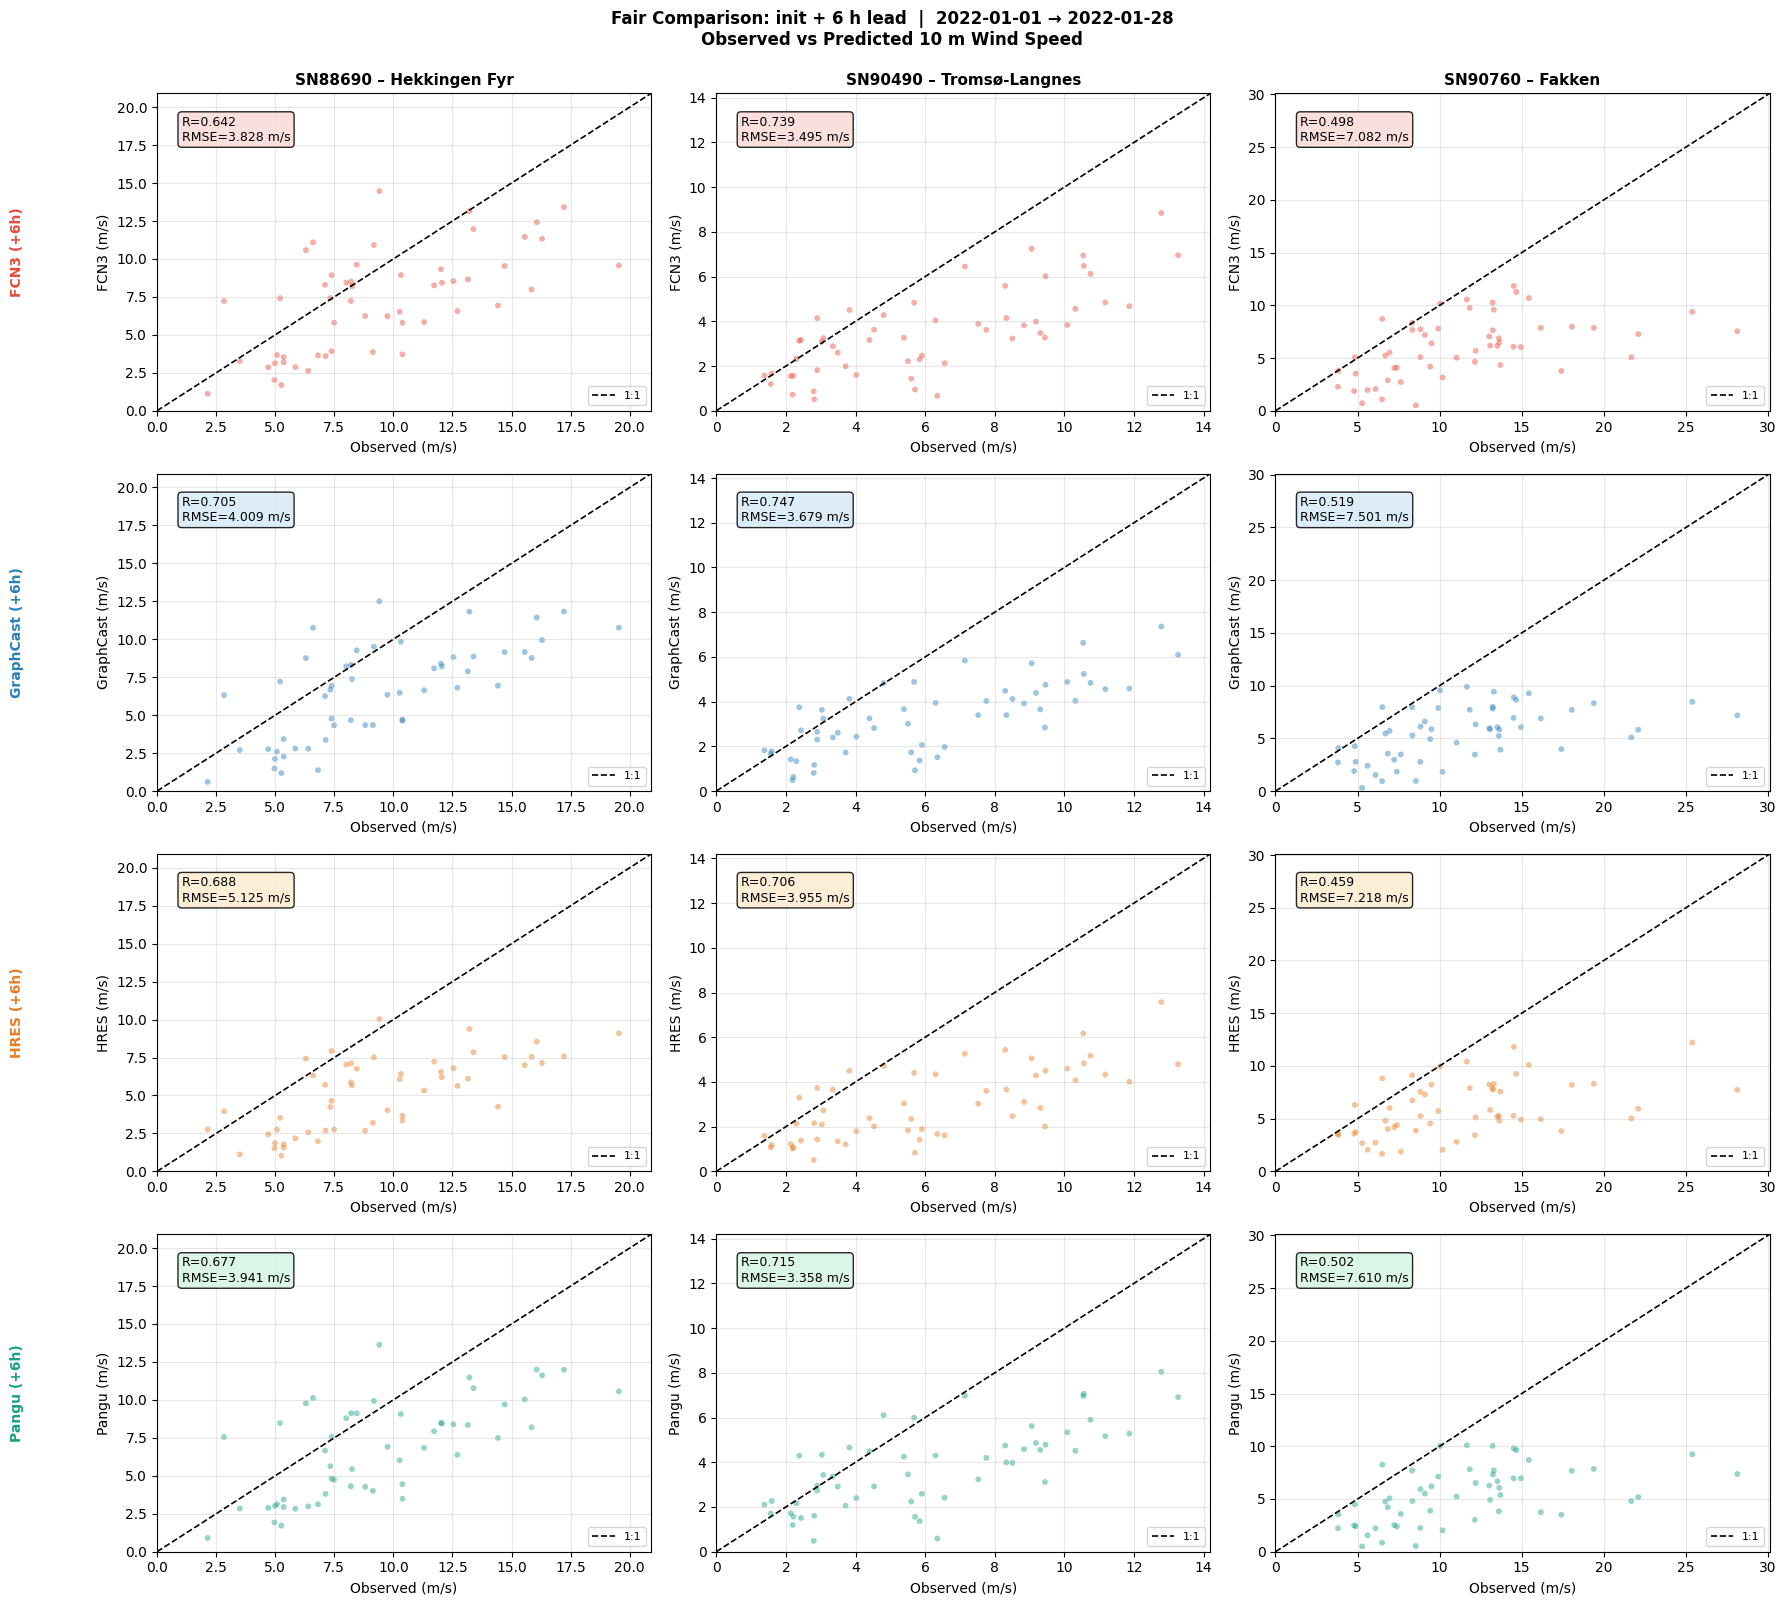

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022/comparison_scatter.png


In [61]:
model_rows = [
    ('fcn3_wind',  'FCN3',      'FCN3 RMSE',      CLR['FCN3'],      '#FADBD8'),
    ('gc_wind',    'GraphCast', 'GraphCast RMSE',  CLR['GraphCast'], '#D6EAF8'),
    ('hres_wind',  'HRES',      'HRES RMSE',       CLR['HRES'],      '#FDEBD0'),
    ('pangu_wind', 'Pangu',     'Pangu RMSE',      CLR['Pangu'],     '#D5F5E3'),
]
_n   = len(STATIONS)
_m   = len(model_rows)
fig, axes = plt.subplots(_m, _n, figsize=(5 * _n + 3, 4 * _m), squeeze=False)

for col, (sid, info) in enumerate(STATIONS.items()):
    sub  = merged[merged['station'] == sid]
    vmax = max(sub[['obs_wind', 'fcn3_wind', 'gc_wind', 'hres_wind', 'pangu_wind']].max()) * 1.07

    for row_i, (wind_col, label, rmse_key, clr, fc) in enumerate(model_rows):
        ax = axes[row_i, col]
        ax.scatter(sub['obs_wind'], sub[wind_col], alpha=0.45, s=18, color=clr, edgecolors='none')
        ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
        ax.set_xlabel('Observed (m/s)', fontsize=10)
        ax.set_ylabel(f'{label} (m/s)', fontsize=10)
        if row_i == 0:
            ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
        r = np.corrcoef(sub['obs_wind'], sub[wind_col])[0, 1]
        ax.text(0.05, 0.93, f'R={r:.3f}\nRMSE={metrics.loc[sid, rmse_key]:.3f} m/s',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.85))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.05, 0, 1, 0.97])
for row_i, (_, label, _, clr, _) in enumerate(model_rows):
    bbox  = axes[row_i, 0].get_position()
    y_mid = (bbox.y0 + bbox.y1) / 2
    fig.text(0.01, y_mid, f'{label} (+{LEAD_H}h)', va='center', rotation='vertical',
             fontsize=10, fontweight='bold', color=clr)

fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'Observed vs Predicted 10 m Wind Speed',
    fontsize=12, fontweight='bold', y=1.00
)
out = FIG_DIR / 'comparison_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 9  Accuracy Scatter (+/-2 m/s Tolerance Band)

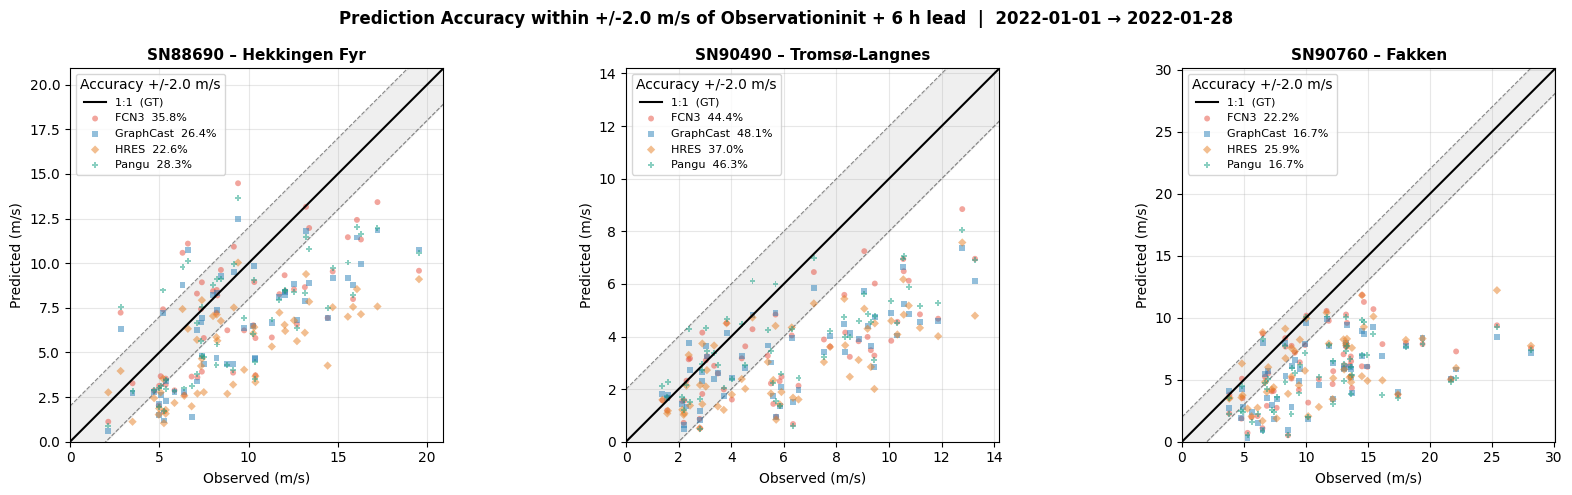

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_gc_pangu_hres_2022/comparison_accuracy_scatter.png


In [57]:
TOLERANCE = 2.0  # m/s

_n   = len(STATIONS)
fig, axes = plt.subplots(1, _n, figsize=(5 * _n + 2, 5), squeeze=False)
axes = axes[0]

model_layers = [
    ('fcn3_wind',  'FCN3',      CLR['FCN3'],      'o'),
    ('gc_wind',    'GraphCast', CLR['GraphCast'], 's'),
    ('hres_wind',  'HRES',      CLR['HRES'],      'D'),
    ('pangu_wind', 'Pangu',     CLR['Pangu'],     'P'),
]

for col, (sid, info) in enumerate(STATIONS.items()):
    ax   = axes[col]
    sub  = merged[merged['station'] == sid]
    vmax = max(sub[['obs_wind', 'fcn3_wind', 'gc_wind',
                     'hres_wind', 'pangu_wind']].max()) * 1.07
    x    = np.linspace(0, vmax, 200)

    ax.fill_between(x, x - TOLERANCE, x + TOLERANCE,
                    alpha=0.12, color='gray', zorder=1)
    ax.plot(x, x + TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x - TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x, 'k-', lw=1.5, label='1:1  (GT)', zorder=5)

    for wind_col, label, clr, marker in model_layers:
        if wind_col not in sub.columns:
            continue
        s2 = sub.dropna(subset=[wind_col])
        obs_v  = s2['obs_wind'].values
        pred_v = s2[wind_col].values
        acc    = 100.0 * (np.abs(pred_v - obs_v) <= TOLERANCE).mean()
        ax.scatter(obs_v, pred_v, alpha=0.50, s=18, color=clr, marker=marker,
                   edgecolors='none', zorder=3,
                   label=f'{label}  {acc:.1f}%')

    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Observed (m/s)', fontsize=10)
    ax.set_ylabel('Predicted (m/s)', fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left', title=f'Accuracy +/-{TOLERANCE} m/s')
    ax.grid(alpha=0.3)

fig.suptitle(
    f'Prediction Accuracy within +/-{TOLERANCE} m/s of Observation'
    f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
out = FIG_DIR / 'comparison_accuracy_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 10  Summary Table

In [62]:
models  = ['FCN3', 'GraphCast', 'HRES', 'Pangu']
present = [m for m in models if f'{m} RMSE' in metrics.columns]

summary = metrics[[c for m in present for c in [f'{m} RMSE', f'{m} MSE', f'{m} Bias'] if c in metrics.columns]].copy()
if 'FCN3 RMSE' in summary.columns:
    for m in [m for m in present if m != 'FCN3']:
        summary[f'ΔRMSE {m}−FCN3'] = summary[f'{m} RMSE'] - summary['FCN3 RMSE']

print(f'Final Summary  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 120)
print(summary.round(4).to_string())

Final Summary  |  lead = +6 h  |  2022-01-01 → 2022-01-28
              FCN3 RMSE  FCN3 MSE  FCN3 Bias  GraphCast RMSE  GraphCast MSE  GraphCast Bias  HRES RMSE  HRES MSE  HRES Bias  Pangu RMSE  Pangu MSE  Pangu Bias  ΔRMSE GraphCast−FCN3  ΔRMSE HRES−FCN3  ΔRMSE Pangu−FCN3
Station                                                                                                                                                                                                                
SN88690          3.8279   14.6526    -2.1814          4.0089        16.0716         -2.8320     5.1248   26.2640    -4.2208      3.9412    15.5330     -2.5948                0.1811           1.2970            0.1133
SN90490          3.4951   12.2159    -2.6552          3.6792        13.5363         -2.8418     3.9553   15.6442    -3.1200      3.3582    11.2778     -2.3949                0.1840           0.4601           -0.1369
SN90760          7.0823   50.1586    -5.3836          7.5006        56.2589   